TSlearn workshop
================

Dataset description https://data.mendeley.com/datasets/wjpbtgdyzm/2

TSlearn documentation: https://tslearn.readthedocs.io/en/latest/

## Setup

In [1]:
%%capture
%pip install --extra-index-url https://download.pytorch.org/whl/cpu 'tslearn[all_features] @ https://github.com/tslearn-team/tslearn/archive/main.zip'

import sys
colab = 'google.colab' in sys.modules
if colab:
    import google.colab
    print(f"Google Colab Version: {google.colab.__version__}")

    !git clone https://github.com/ia-p16/tslearn-workshop-2026.git
    import os
    os.chdir("tslearn-workshop-2026")

The utils module available for this workshop, provides functions for data retrieval and visualization.
`get_X_y` is notably used to retrieve data with imus being sequenced as ["back", "lla", "lua", "rla", "rt", "rua"]. Available features are
 ["x-acc", "y-acc", "z-acc", "x-vel", "y-vel", "z-vel"].

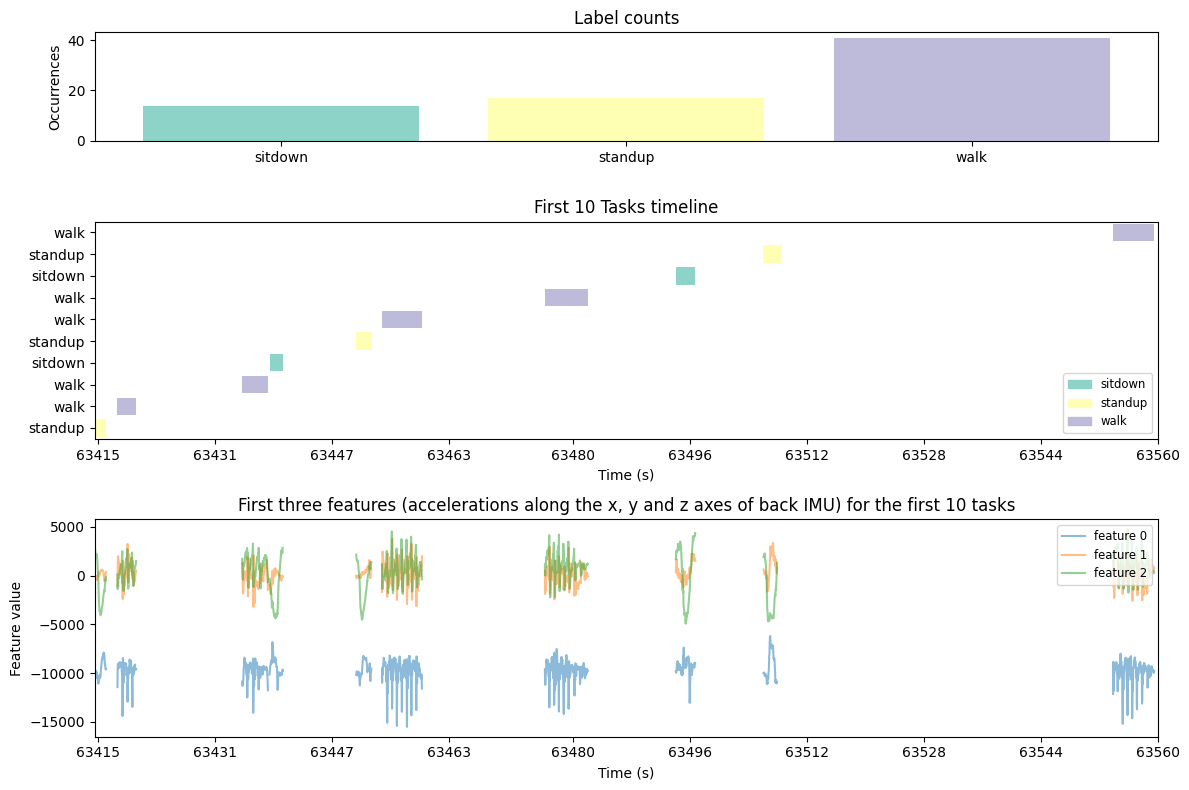

In [2]:
from utils import get_X_y, visualize_dataset_overview
import numpy as np

dataset, tasks = get_X_y(volunteers=[1], task_labels=["sitdown", "standup", "walk"], features=["x-acc", "y-acc", "z-acc"])
labels = np.array(tasks)[:, 2]
visualize_dataset_overview(labels, tasks, dataset)

## Preprocessing

In [3]:
dataset, tasks = get_X_y()
labels = np.array(tasks)[:, 2]
dataset.shape, labels.shape

((1839, 319, 36), (1839,))

💡 Take some time to figure out / remember what the dataset shape represents...

### Impute

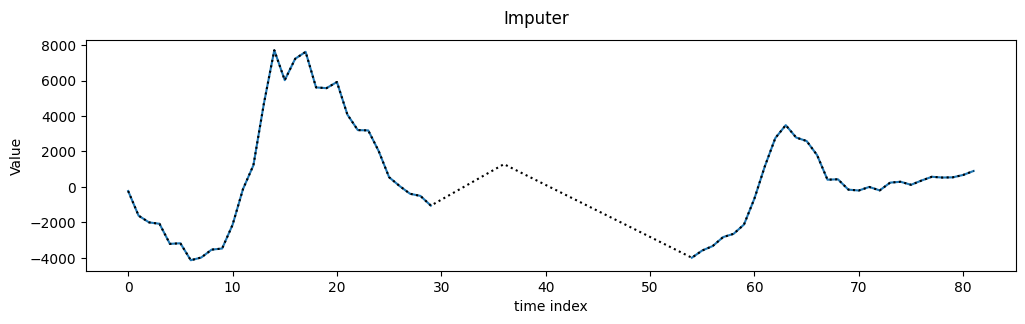

In [4]:
# Imputer: this particular time series has missing data
# corresponding to the lla imu (feature 6 to 11)
task = 1081
feature = 10

from tslearn.preprocessing import TimeSeriesImputer
imputed = TimeSeriesImputer(method="linear", keep_trailing_nans=True).fit_transform(dataset[task, :, feature].reshape(1, -1))

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 3))
fig.suptitle('Imputer')
plt.plot(dataset[task, :, feature])
plt.plot(imputed.reshape(-1), 'k:')
plt.ylabel("Value")
plt.xlabel("time index")
plt.show()

💡 Take some time to play with the TimeSeriesImputer parameters

### Resample

By default, the size of the longuest timeseries in the whole dataset is used.

In [5]:
from tslearn.preprocessing import TimeSeriesResampler
from tslearn.utils import ts_size

resampled_dataset = TimeSeriesResampler(sz=300).fit_transform(dataset)
ts_size(dataset[0]), ts_size(resampled_dataset[0]), dataset.shape[1], resampled_dataset.shape[1]

(106, 300, 319, 300)

### Scale

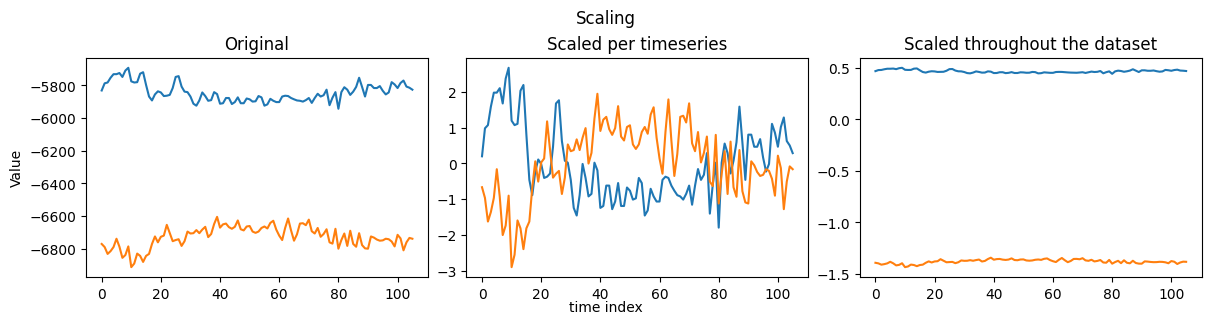

In [6]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
per_ts = TimeSeriesScalerMeanVariance(per_timeseries=True, per_feature=True).fit_transform(dataset)
all_ts = TimeSeriesScalerMeanVariance(per_timeseries=False, per_feature=True).fit_transform(dataset)

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle('Scaling')
fig.text(0.5, -0.02, 'time index', ha='center')
ax = axs[0]
ax.set_ylabel("Value")
ax.plot(dataset[0, :, 6])
ax.plot(dataset[0, :, 7])
ax.set_title('Original')
ax = axs[1]
ax.plot(per_ts[0, :, 6])
ax.plot(per_ts[0, :, 7])
ax.set_title('Scaled per timeseries')
ax = axs[2]
ax.plot(all_ts[0, :, 6])
ax.plot(all_ts[0, :, 7])
ax.set_title('Scaled throughout the dataset')
plt.show()


## Clustering

In [7]:
task_labels = ["walk", "standup", "sitdown"]
volunteers =  [1]
imus = None
features = ["x-acc", "y-acc", "z-acc"]

n_clusters = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, features=features, task_labels=task_labels)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

(72, 226, 18) ['walk: 41', 'standup: 17', 'sitdown: 14']


### sklearn KMEANS

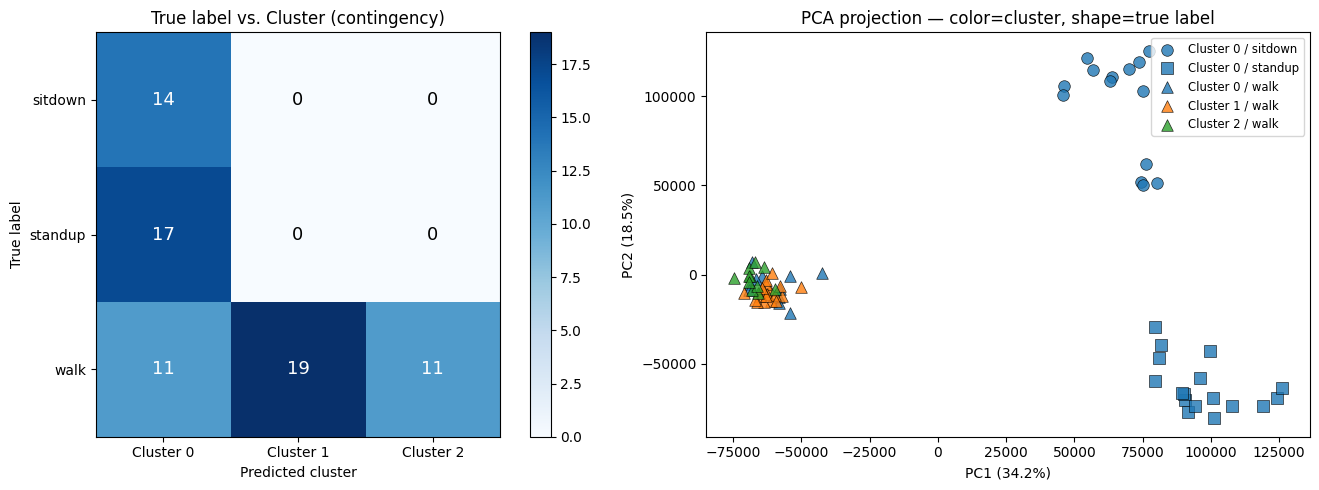

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing  import StandardScaler
from sklearn.cluster import KMeans

from tslearn.utils import to_sklearn_dataset

from utils import visualize_clustering_results

sk_dataset = to_sklearn_dataset(dataset)
sk_dataset = SimpleImputer(strategy="constant", fill_value =0.0).fit_transform(sk_dataset)
sk_dataset = StandardScaler().fit_transform(sk_dataset)
cl_sk_kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(sk_dataset)

visualize_clustering_results(cl_sk_kmeans, dataset, labels)

### tslearn KMEANS with DTW metric

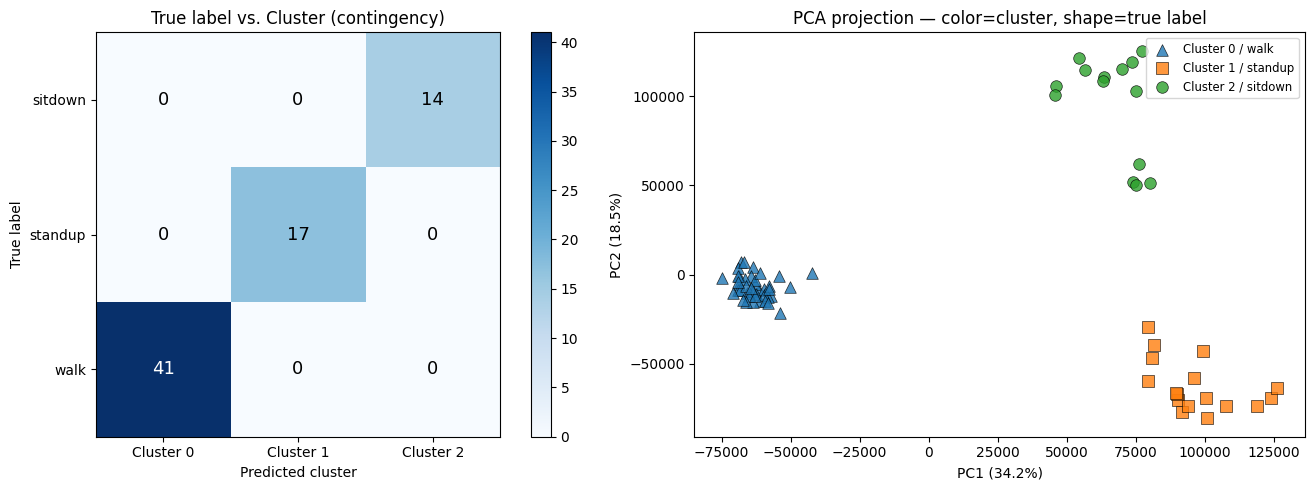

In [9]:
# Perform KMEANS clustering using tslearn and visualize results
# You might want to take a look at the computed attributes after
# clustering is performed
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesImputer, TimeSeriesScalerMeanVariance

tslearn_dataset = TimeSeriesImputer(keep_trailing_nans=True).fit_transform(dataset)
tslearn_dataset = TimeSeriesScalerMeanVariance(per_timeseries=False, per_feature=False).fit_transform(tslearn_dataset)
cl_ts_kmeans = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=0).fit(tslearn_dataset)

visualize_clustering_results(cl_ts_kmeans, dataset, labels)

In [10]:
# Use the `silhouette score` to evaluate cluster quality.
# This metric measures how similar each point is to its own cluster compared to other clusters,
# ranging from -1 (poor clustering) to +1 (well-separated clusters). A higher score indicates better-defined, more distinct clusters.
from tslearn.clustering import silhouette_score

sil_score = silhouette_score(tslearn_dataset, cl_ts_kmeans.labels_, metric="dtw")

print(f"Silhouette score for KMeans clustering: {sil_score:.4f}")

Silhouette score for KMeans clustering: 0.4262


## Classification

In [26]:
task_labels = ["sitdown", "drinkglass", "walk", "opendoor", "cleantable", "brushteeth"]
volunteers =  [1]
imus = ["back"]
features = ["z-acc"]
n_classes = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, features=features, task_labels=task_labels)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

(129, 272, 1) ['sitdown: 14', 'drinkglass: 24', 'walk: 41', 'opendoor: 17', 'cleantable: 18', 'brushteeth: 15']


In [27]:
# split the dataset while preserving the label distribution (stratification) and shuffling the data
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)
for x in np.unique(labels):
    print(x,
          "train", len(np.argwhere(train_labels==x)),
          "test", len(np.argwhere(test_labels==x)),
          "total", len(np.argwhere(labels==x)),
          "test%", np.round((len(np.argwhere(test_labels==x)) / len(np.argwhere(labels==x))), 2) if len(np.argwhere(labels==x)) > 0 else 0.0)

brushteeth train 10 test 5 total 15 test% 0.33
cleantable train 12 test 6 total 18 test% 0.33
drinkglass train 17 test 7 total 24 test% 0.29
opendoor train 12 test 5 total 17 test% 0.29
sitdown train 10 test 4 total 14 test% 0.29
walk train 29 test 12 total 41 test% 0.29


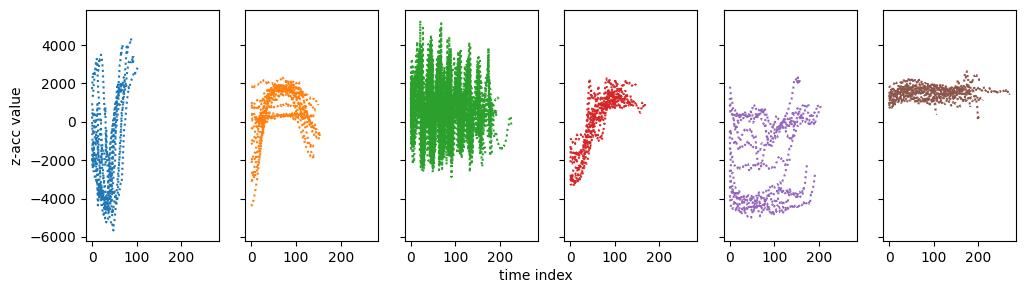

In [28]:
# Visualize data
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, n_classes, figsize=(12, 3), sharex=True, sharey=True)
axs[0].set_ylabel('z-acc value')
fig.text(0.5, -0.02, 'time index', ha='center')
colors = plt.get_cmap("tab10").colors

for i in range(n_classes):
    for x in train_data[train_labels==task_labels[i]]:
        for imu_index in range(len(imus)):
            for feature_index in range(len(features)):
                axs[i].plot(x[..., feature_index + imu_index * 3],
                            linestyle=":",
                            color=colors[i])

### KNN example

#### sklearn KNN

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

from tslearn.preprocessing import TimeSeriesResampler
from tslearn.utils import to_sklearn_dataset

equal_size_train_data = TimeSeriesResampler().fit_transform(train_data)
sk_train_data = to_sklearn_dataset(equal_size_train_data)

sk_knn = KNeighborsClassifier()
parameters = {'n_neighbors': list(range(1, 6))}
sk_grid = GridSearchCV(sk_knn, parameters).fit(sk_train_data, train_labels)

mean_scores = np.array(sk_grid.cv_results_["mean_test_score"])
print(mean_scores)

[0.78888889 0.65555556 0.65555556 0.6        0.62222222]


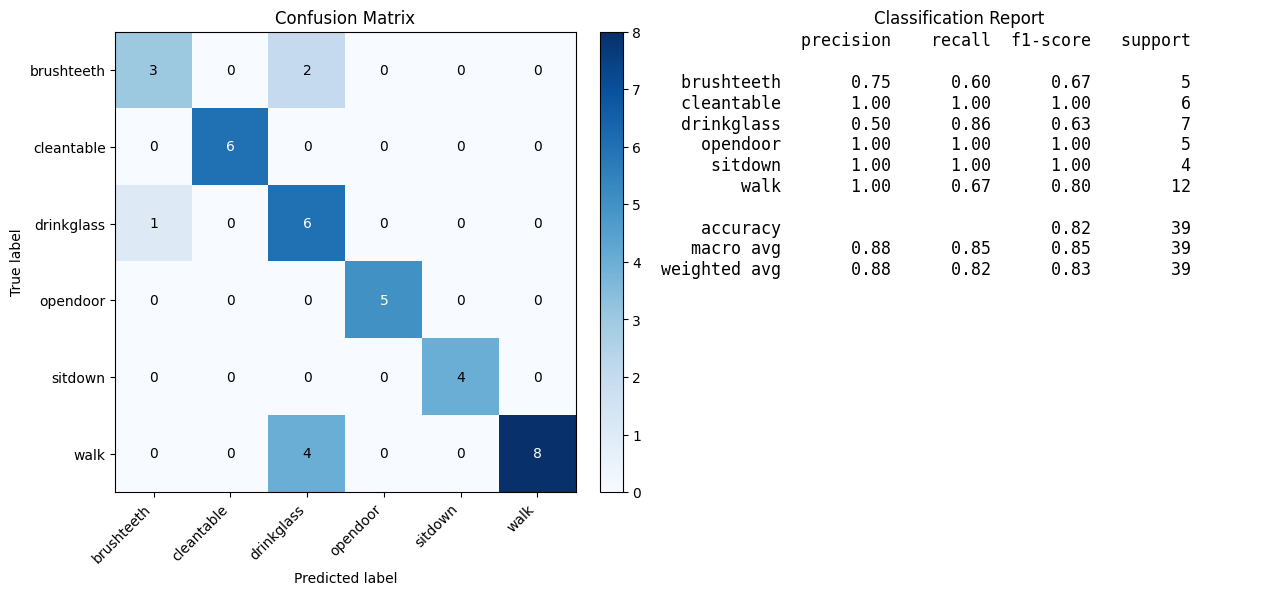

In [30]:
from utils import visualize_classification_results

equal_size_test_data = TimeSeriesResampler(equal_size_train_data.shape[1]).fit_transform(test_data)
sklearn_test_data = to_sklearn_dataset(equal_size_test_data)
y_pred_euclidean = sk_grid.predict(sklearn_test_data)

visualize_classification_results(sk_grid, test_labels, y_pred_euclidean)

### tslearn KNN with DTW metric

In [34]:
# Perform KNN classification using tslearn and visualize results
# You might want to take a look at the computed attributes after
# classification is performed
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

ts_knn = KNeighborsTimeSeriesClassifier()
parameters = {'n_neighbors': list(range(1, 6))}
tslearn_grid = GridSearchCV(ts_knn, parameters).fit(train_data, train_labels)

mean_scores = np.array(tslearn_grid.cv_results_["mean_test_score"])
print(mean_scores)

[0.94444444 0.92222222 0.91111111 0.87777778 0.88888889]


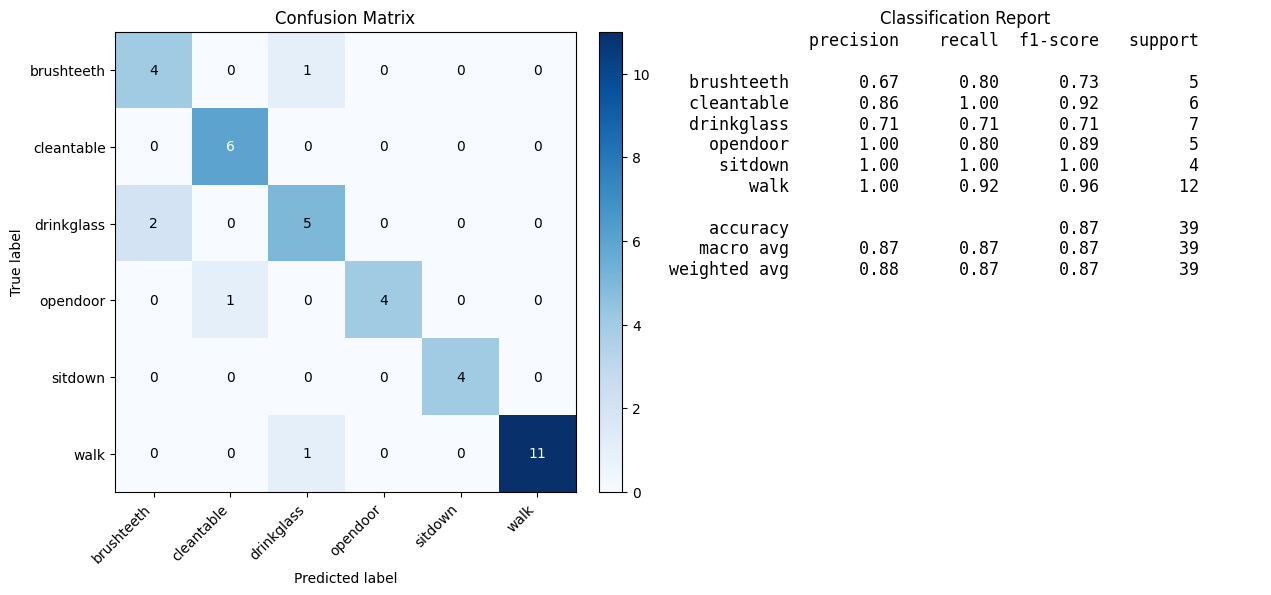

In [35]:
y_pred_dtw = tslearn_grid.predict(test_data)
visualize_classification_results(tslearn_grid, test_labels, y_pred_dtw)

### Shapelets model

In [59]:
task_labels = ["standup", "sitdown"]
volunteers =  [1]
n_classes = len(task_labels)
imus = ["rt"]
features = ["x-acc"]

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, features=features, task_labels=task_labels, min_size=30)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

(31, 103, 1) ['standup: 17', 'sitdown: 14']


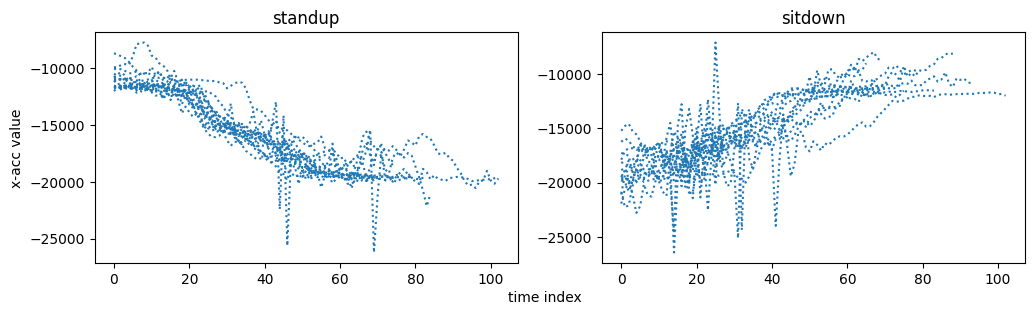

In [60]:
# Visualize data
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, n_classes, figsize=(12, 3))
fig.text(0.5, -0.02, 'time index', ha='center')
axs[0].set_ylabel('x-acc value')
colors = plt.get_cmap("tab10").colors

for i in range(n_classes):
    for x in dataset[labels==task_labels[i]]:
        for imu_index in range(len(imus)):
            for feature_index in range(len(features)):
                axs[i].set_title(task_labels[i])
                axs[i].plot(x[..., feature_index + imu_index * len(features)], linestyle=':', color=colors[feature_index])

In [61]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)
for x in np.unique(labels):
    print(x,
          "train", len(np.argwhere(train_labels==x)),
          "test", len(np.argwhere(test_labels==x)),
          "total", len(np.argwhere(labels==x)),
          "test%", np.round((len(np.argwhere(test_labels==x)) / len(np.argwhere(labels==x))), 2) if len(np.argwhere(labels==x)) > 0 else 0.0)


sitdown train 9 test 5 total 14 test% 0.36
standup train 12 test 5 total 17 test% 0.29


In [69]:
from tslearn.shapelets import LearningShapelets

from utils import visualize_classification_results

shapelet_clf = LearningShapelets(
    n_shapelets_per_size={30: 2},
    scale=True,
    random_state=0,
    max_iter=350,
    batch_size=16,
    optimizer="adam"
).fit(train_data, train_labels)

y_pred_shapelets = shapelet_clf.predict(test_data)

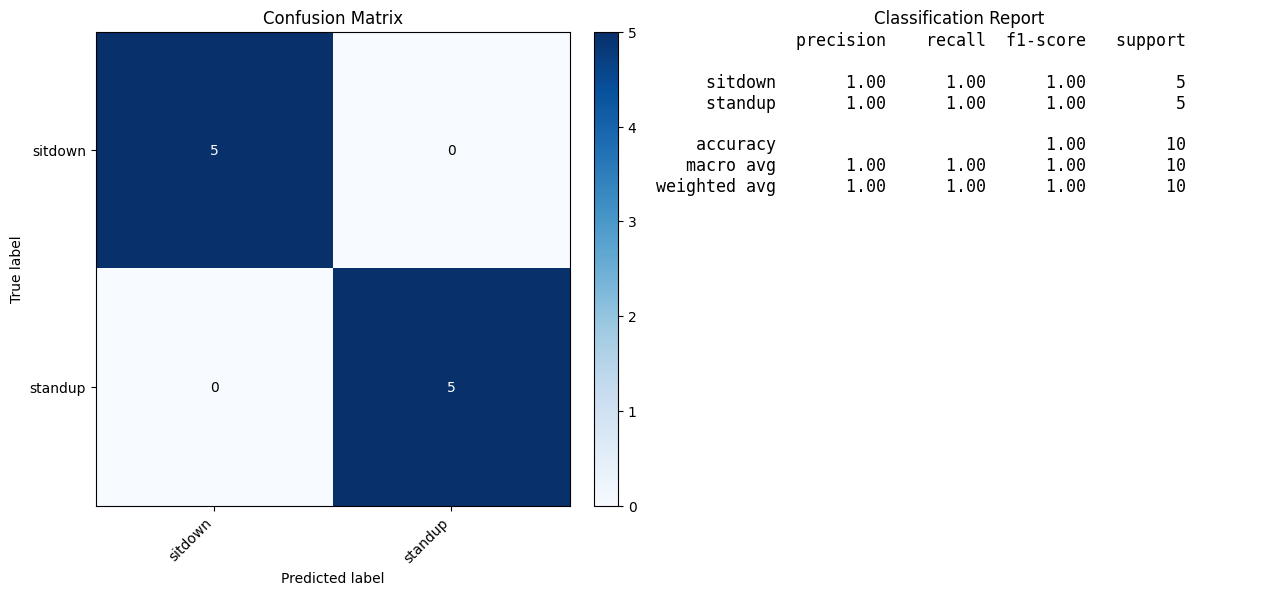

In [70]:
visualize_classification_results(shapelet_clf, test_labels, y_pred_shapelets)

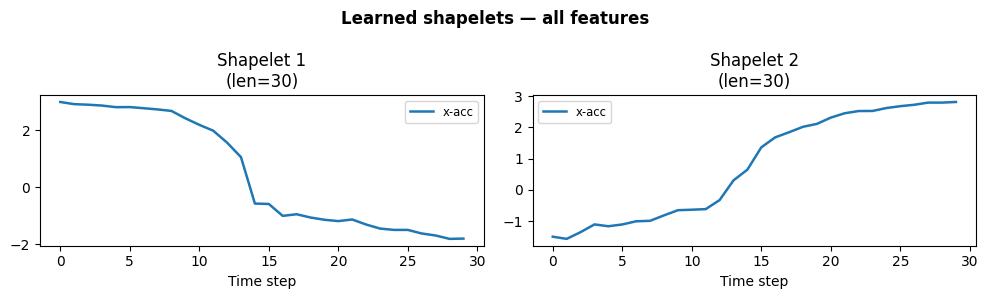

In [42]:
# visualize learned shapelets (one plot per shapelet, all features in each plot)
from utils import visualize_shapelets

visualize_shapelets(shapelet_clf, feature_names=features)

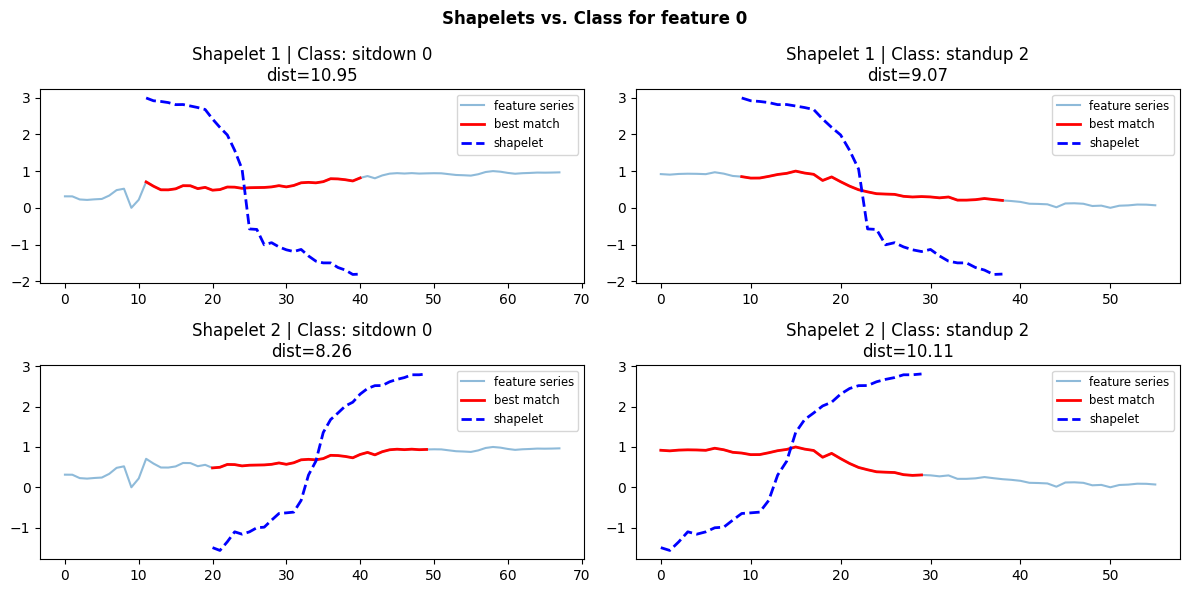

In [43]:
from tslearn.preprocessing import TimeSeriesScalerMinMax

from utils import visualize_shapelet_matches

visualize_shapelet_matches(shapelet_clf, TimeSeriesScalerMinMax().fit_transform(train_data), train_labels, show_feature=0)

### Large scale shapelets

In [44]:
# Given the following dataset, perform classification using the shapelet models

task_labels = ["walk", "standup", "sitdown"]
volunteers =  None
imus = ["back"]
features = None
n_classes = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, features=features, task_labels=task_labels, min_size=30)
labels = np.array(tasks)[:, 2]
train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)
print(x,
          "train", len(np.argwhere(train_labels==x)),
          "test", len(np.argwhere(test_labels==x)),
          "total", len(np.argwhere(labels==x)),
          "test%", np.round((len(np.argwhere(test_labels==x)) / len(np.argwhere(labels==x))), 2) if len(np.argwhere(labels==x)) > 0 else 0.0)


task 43 [64093615, 64094179, 'walk'] of size 19 skipped
task 211 [67835124, 67835965, 'standup'] of size 28 skipped
task 276 [68613173, 68614013, 'standup'] of size 28 skipped
task 303 [70360570, 70361410, 'standup'] of size 28 skipped
task 307 [70386530, 70387370, 'standup'] of size 28 skipped
task 330 [70719286, 70720006, 'standup'] of size 24 skipped
task 359 [72091173, 72091773, 'walk'] of size 20 skipped
task 403 [72703309, 72704149, 'standup'] of size 28 skipped
task 412 [72811583, 72812423, 'standup'] of size 28 skipped
task 449 [35145327, 35146168, 'standup'] of size 28 skipped
task 489 [35718309, 35719151, 'standup'] of size 28 skipped
task 520 [56995673, 56996395, 'standup'] of size 24 skipped


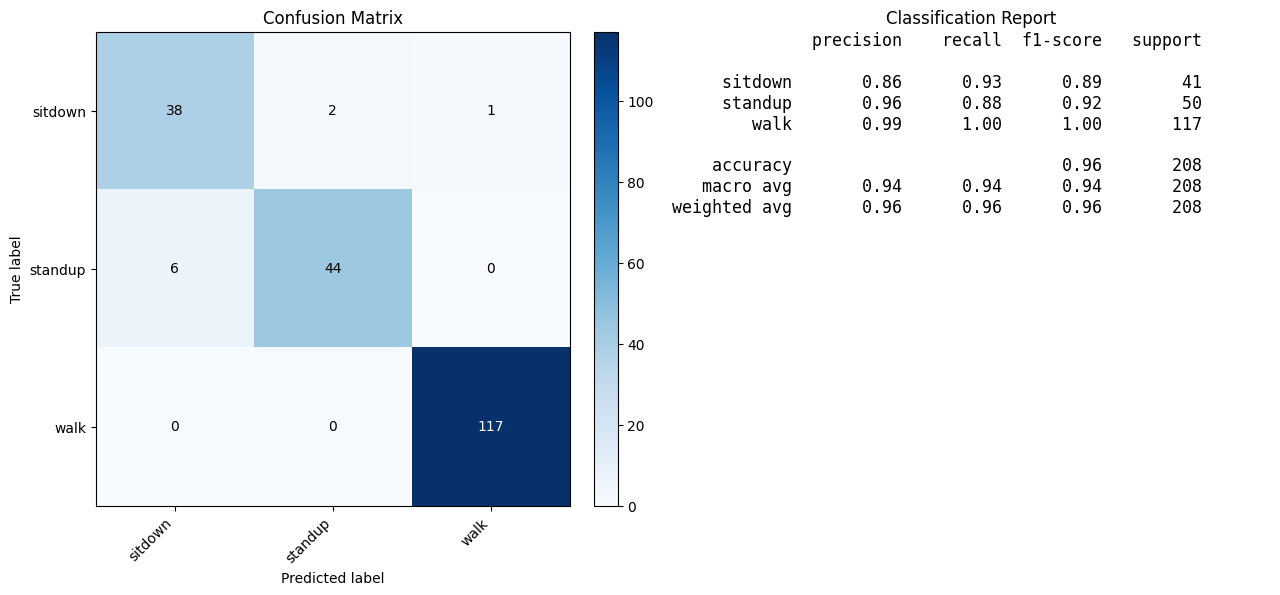

In [45]:
shapelet_clf = LearningShapelets(
    n_shapelets_per_size={30: 2},
    scale=True,
    random_state=0,
    max_iter=500,
    batch_size=16,
    optimizer="adam"
).fit(train_data, train_labels)

y_pred_shapelets = shapelet_clf.predict(test_data)

visualize_classification_results(shapelet_clf, test_labels, y_pred_shapelets)